In [1]:
import sys
from pathlib import Path

%matplotlib widget

class ImportMyModules:

    def __init__(self) -> None:
        self.cwd = Path.cwd().resolve()

    def _get_repo_root(self, folder: str) -> Path:
        return next(
            parent for parent in [self.cwd, *self.cwd.parents]
            if (parent / "lib" / "peregrin" / folder).exists()
        )

    def insert_path(self, folder: str) -> None:
        repo_root = self._get_repo_root("src")

        package_root = repo_root / "lib" / "peregrin"
        print(f"Adding {package_root} to sys.path")
        sys.path.insert(0, str(package_root))

importer = ImportMyModules()
importer.insert_path("src")
importer.insert_path("data")

from importlib import reload

Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path
Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path


In [2]:
import src.loader.load as load_module
import src.batch.tree as tree_module
reload(load_module)
reload(tree_module)
load_data = load_module.load_data
make_tree = tree_module.make_tree

data = load_data(r"./dummy_data/single/dummy_cell_tracks.csv", {'id': 'track_id', 'x': 'x_coordinate', 'y': 'y_coordinate', 't': 'time_point'}, spatial_unit="micrometer", time_unit="second")

tree = make_tree(r"./dummy_data/tree/")
data = load_data(tree.get(), {'id': 'track_id', 'x': 'x_coordinate', 'y': 'y_coordinate', 't': 'time_point'}, spatial_unit="micrometer", time_unit="second")

import src.compute.stats as stats_module
reload(stats_module)
_data_object = stats_module.create_object

data_object = _data_object(data)


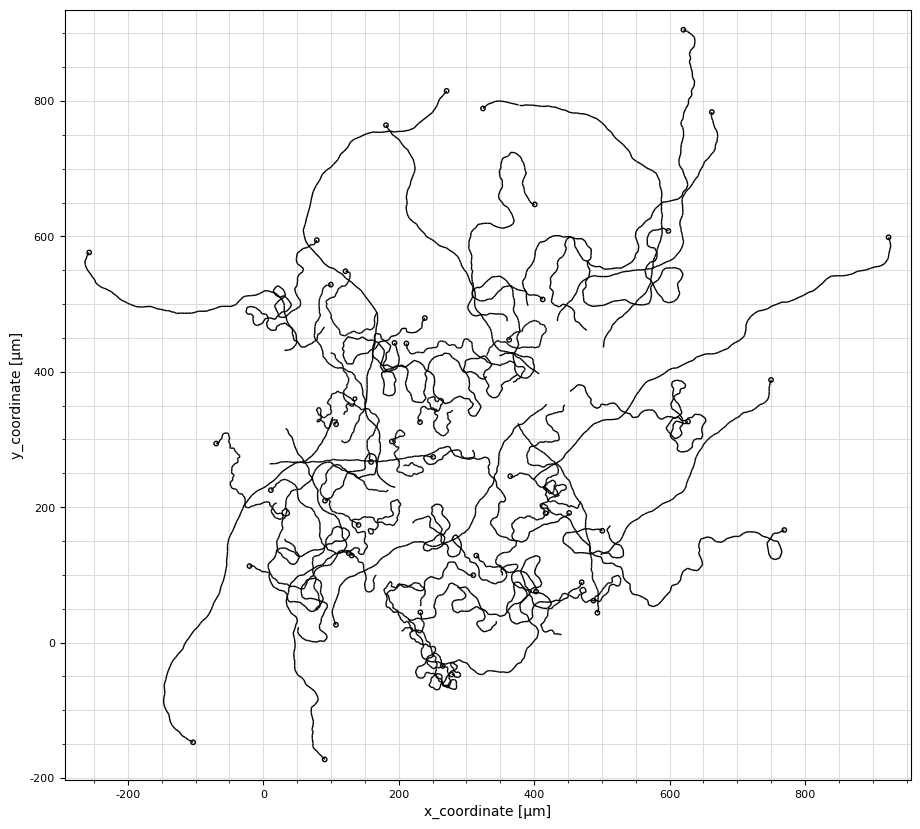

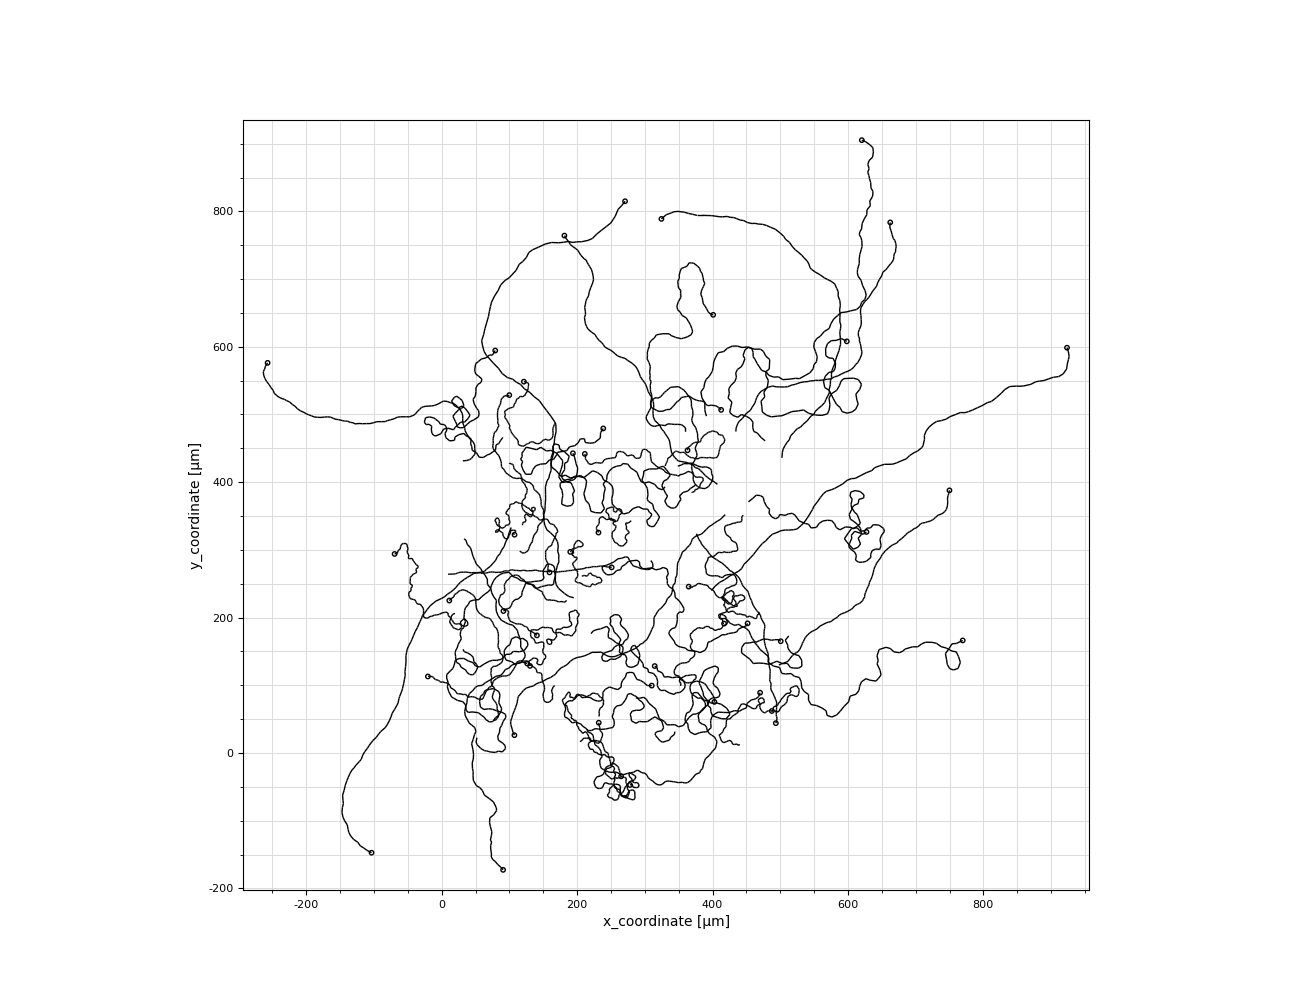

In [3]:
data_object.plot_tracks()

In [6]:
plot = data_object.plot_tracks(fmt="html", show_ids=True)
plot

In [5]:
# plot.save(r"./test_track_reconstruction.html")

import io

with io.open(r"./test_track_reconstruction.html", "w", encoding="utf-8") as f:
    f.write(plot.to_html())

AttributeError: 'ReconstructTracks' object has no attribute 'to_html'